In [82]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')
    
    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)
    
        

    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)
    

def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):
    
    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]
    
    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)
    
    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')
    
    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])

    
    return X_train,y_train,X_val,y_val,X_test,y_test

In [83]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes
#i've got mighty gpu but it doesn't work for me, womp womp
import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)



2.20.0
3.13.2


In [84]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer", 
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

C:\Users\Sergej\AppData\Local\Temp\ipykernel_15556\4062928930.py:22: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo,encoding='latin1')


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


Downloaded our samples, we've got 40k images in 32x32 shape. What is the fourth number though? the Z axis? 

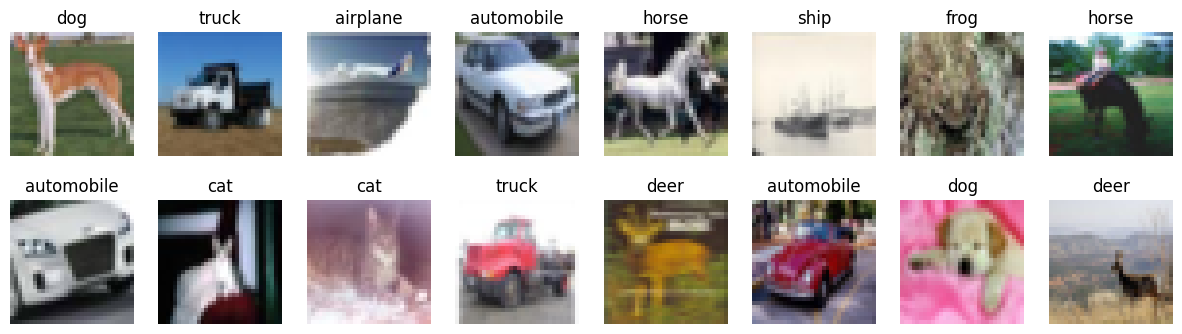

In [85]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [86]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [87]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization
from tensorflow.keras import layers

In [88]:
from xml.parsers.expat import model


def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """
    model = Sequential()
    
    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network. 

    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3), padding='same'))
    #padding here is a recommendation based on the fact we use an image, it shouuld result in less info loss

    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), padding='same', activation='relu')) #another paired layer
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    
    #according to: https://www.geeksforgeeks.org/deep-learning/tanh-vs-sigmoid-vs-relu/ 
    #relu is the most advantageous in our MLP CNN situation 
    ### Then, add a Pooling layer to pick up the relevant kernels.
    #so 2x2 pooling takes the max value, combined with relu this should synergize 
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,

    #add another layer let's see if it helps
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    #let's do another layer and then flatten
    model.add(Flatten()) 
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    
    #dropout being larger for the last layer is another prevention for overfitting
    #finally make 10 outputs 

    model.add(Dense(units=10, activation='softmax'))


    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    #THIS IS NOT THE FINAL RATE, it is better to check later 

    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.

    ### END STUDENT CODE ### 

    # Ensure normalized probabilities over the 10 classes 
    return model
   

In [89]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training

INIT_LR = 5e-3 # initial learning rate #bigger steps make bigger LR, whereas smaller steps are done by maing LR smaller - we adjust this to the data 
BATCH_SIZE = 64
EPOCHS = 100


K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model

# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adam(learning_rate=INIT_LR),  # for SGD.
    metrics=['accuracy']  # report accuracy during training
)
#changed adamax to adam

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',    
    patience=12,            #Number of epochs to wait for improvement
    restore_best_weights=True # Revert to the best model weights
)
#added early stopping in case of overfitting - 12-8 patience should be fair enough

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)

# fit model
model.fit(
    x_train, y_train,  # prepared data
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[early_stopping]
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.4594 - loss: 1.5445 - val_accuracy: 0.4826 - val_loss: 1.4918
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.6364 - loss: 1.0333 - val_accuracy: 0.5321 - val_loss: 1.3999
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.7038 - loss: 0.8438 - val_accuracy: 0.5909 - val_loss: 1.2551
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7466 - loss: 0.7339 - val_accuracy: 0.5929 - val_loss: 1.2845
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7723 - loss: 0.6603 - val_accuracy: 0.6701 - val_loss: 0.9916
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7926 - loss: 0.6061 - val_accuracy: 0.5030 - val_loss: 1.6389
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8056 - loss: 0.5605 - val_accuracy: 0.7021 - val_loss: 0.8989
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.8172 - loss: 0

1st prototype run: Batch=32 | Epochs=5 | Steps=5e-3 | accuracy value = 0.09 
Wow that sucks 

2nd run: Batch=64 | Epochs=10 | Steps=5e-1 | accuracy value = 0.0975 
alright getting somewhere, let's change dropout to less (from 50% to 35%)

3rd run: Batch=48 | Epochs=10 | Steps=5e-2 | accuracy value = 0.14 - changed dropout to none 
WE'RE CLIMBING!

4th run: Batch=48 | Epochs=15 | Steps=5e-1 | accuracy value = 0.0875 
okay so steps gotta be smaller 

5th run: Batch=32 | Epochs=15 | Steps=5e-3 | accuracy value = 0.28 
Wowah wee waa progress, let's see what batches do 

6th: run Batch=16 | Epochs=15 | Steps=5e-3 | accuracy value = 0.19 okay batches gotta be somewhat bigger 

7th: Batch=32 | Epochs= 20 | Steps=5e-2 | accuracy value = 0.42 
i have now realized that i read validation values and not accuracy :)

8th: Batch=48 | Epochs=20 | Steps=5e-3 | acc = 0.49 | valid = 0.32 - alright validation is quite far off we have to solve this somehow, let's try dropout? alright jsut dont bother 

9th; Batch=32 | Epochs=30 | Steps=5e-3 | acc = 0.55 | valid = 0.33ish - let's try dropout of 0.05

10th: Batch=32 | Epochs=30 | Steps=5e-3 | acc = 0.30 | valid = 0.2 - yeah it just sucks, the lerning rate has the sweet spot at 3 

11th: Batch=32 | Epochs=30 | Steps=5e-3 | acc = 0.35| valid = 0.28 - added another layer of ConV - the accuracies are closer so it is beneficial but overall it cuts down a lot 

12th: Batch=32 | Epochs=30 | Steps=5e-3 | acc = 0.84| valid = 0.46 - readjusted the make funct. - wow the accuracy is amazing but the validation is far off

13th: Batch=32 | Epochs=30 | Steps=5e-3 | acc = 0.78| valid = 0.42 - - addded another layer of kernel, the layer did not help as much as I thought.

14th: Batch=32 | Epochs=30 | Steps=5e-3 | acc = 0.85| valid = 0.50   - added another layer of dropoff after the second layer, okay it does seem to help, let's increase that and add a stopping mechanism 

15th: Batch=32 | Epochs=30 | Steps=5e-3 | acc = 0.81 | valid = 0.49 - curoius, dropout of 10% make sit worse, let's try batch size again and dense 

16th: Batch=32 | Epochs=100 | Steps=5e-3 | acc = 0.64 | valid = 0.38 - added the dense layer additionally - it sucks 

17th: Batch=32 | Epochs=100 | Steps=5e-3 | acc = 0.79| valid = 0.34 - batch normalization added, as well as the same padding, these should reduce information loss and make our validation a bit better - it seems we're stuck 

Let's change batch size to 64 and learning rate lower, we could adjust dropout too but that's for next runs. I have changed the first layer from 32 to 16 that could help in going general to details to general again

18th: Batch=64 | Epochs=100 | Steps=5e-4 | acc = 0.72| valid = 0.46 - Doesn't work, reverted dropout, reverted 16 to 32 

19th: Batch=128 | Epochs=100 | Steps=5e-4 | acc = 0.77| valid = 0.50 - I'll try double layers here, this will be slower but hopefully get a better result

20th: Batch=64 | Epochs=100 | Steps=5e-4 | acc = 0.87| valid = 0.70 - that is incredible, double layers have signficantly increased the accuracy (albeit with a little longer computation) and also brought the acc and valid. closer together 

21st: Batch=64 | Epochs=100 | Steps=5e-3 | acc = 0.73| valid = 0.70 - forgot to add batch normalization after each conv2D, as well as padding. Gonna try e-3 again - okay overall accuracy is a bit lower and validation did not change - hm

22nd: Batch=64 | Epochs=100 | Steps=5e-3 | acc = 0.75| valid = 0.71 - with the addition of the learning rate schedule it loks like we are not climbing as much as i hoped - last try with a third layer 

23rd: Batch=64 | Epochs=100 | Steps=5e-3 | acc = 0.90| valid = 0.75 - okay so even with a third layer the computation is relativelly quick (12 minuttes) and the growth is 4% from before - this is pretty good - adding more layers would probably just slow down the system







In [93]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


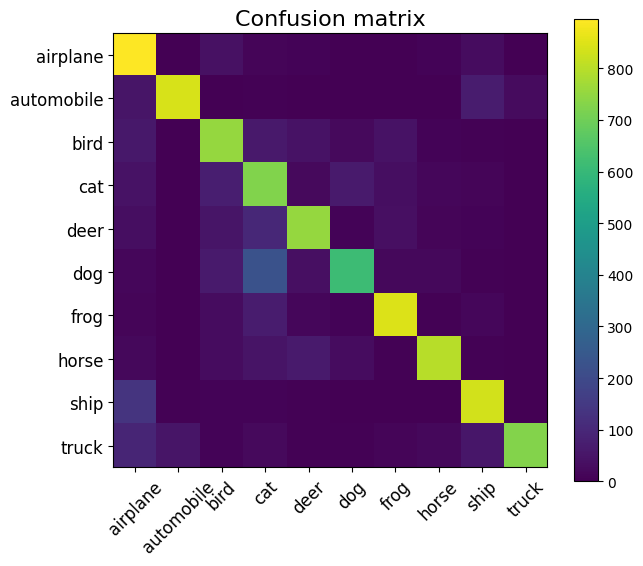

Test accuracy: 0.7794


In [94]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

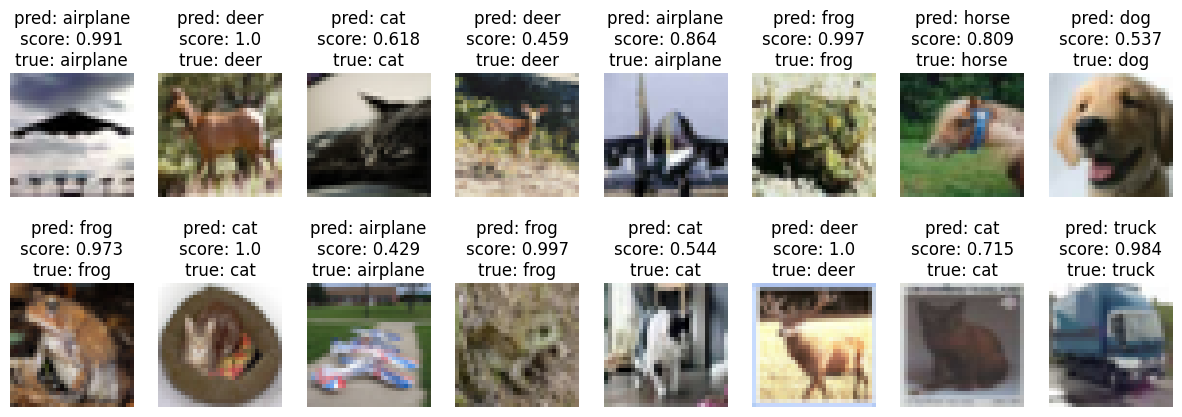

In [92]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons, 
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ - 
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image): 
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




So running this simultion on another computer, turns out it is not super precise. It would be beneficial to cross-run this on two devices with two different data sets. 
Furthermore, Dense should be greater according to some sources (https://stackoverflow.com/questions/43755293/what-does-dense-do) maing dense 512 could help. - So far cannot manage to implement 512. 
Having tried that it seems that the system would be overfitting for 512. 

At more accurate systems, dropout actually makes more sense.
Our accuracy is realtively high but validation accuracy is twice as low, this suggets that my model jumps around the solution - smaller steps 
Batch size 32 is just too slow - 20mins per run is insane, whereas 128 just goes too quick, 64 should be good for my system as of right now.

According to: https://stackoverflow.com/questions/46515248/intuition-behind-stacking-multiple-conv2d-layers-before-dropout-in-cnn - double layer of Conv2D makes greater accuracy since the two can make up for the other's loss of non-linear transformations (since max pooling cuts this info out) - I'll try using that - wow the improvement is incredible

Based on the runtime the accuracy and validation seem to go above the record but then go down in later epochs, there has got to be a way to prevent that. 
According to: https://www.jeremyjordan.me/nn-learning-rate/ - something called the Learning schedule can be made
Based on this: https://keras.io/api/callbacks/reduce_lr_on_plateau/ - we can build a function which will reduce the learning rate when our accuracy stop improving - 1% increase is 1% increase



\\\\\\\ RESULTS \\\\\\\\

Validation accuracy of 77%

- More layers generally sees greater accuracy, that being said it eventually will lead to overfitting if not measures are taken - the more pressng problem is the computation takes AGES. 
- Doubled Conv. layers improve the accuracies significantly this is due to the fact that they synergize with each other in not losing information after processing. 
- Batch normalization - normalization (as in statistical) of the data allows the model to work more efficiently so this is almost never a loss. 
- Learning schedule is excellent is details but it seems the effect is minimal (at least in my case here) 
- Each parameter for batches learning rate and epochs should be adjusted on the dataset bassis, unfortunatelly in my runs it seemed that the parameters which I named prior are volatile with all other aspects of the model so changing one temporarilly does not mean it is the best for the whole model in the long run (batch size 32 in earlier runs was good later on 64 turned out to be the best).
- Bigger batches are better since smaller ones tend to overfit, same for learning rate (statistics shows e^-3 to e^-2 is the best, see 3.).
- Dropout is best kept at chunks of data again it tends to overfit so cutting off larger pieces seems better as the model becomes more elaborate. 
- Epochs can be any number really as long as we have a stopping mechanism in place. 
- RelU for our specific model is the best since we do not care for negative outputs. (This is probably because of the fact we're using images?) Based on the article it introduces non-linearity (even if the function is linear itself).


Sources used:

Claude AI for code optimization and debugging. 

1. https://stackoverflow.com/questions/43755293/what-does-dense-do
2. https://stackoverflow.com/questions/46515248/intuition-behind-stacking-multiple-conv2d-layers-before-dropout-in-cnn
3. https://www.jeremyjordan.me/nn-learning-rate/
4. https://keras.io/api/callbacks/reduce_lr_on_plateau/
5. https://www.geeksforgeeks.org/deep-learning/tanh-vs-sigmoid-vs-relu/ 
